In [18]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

In [19]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"sadanalakarthik123","key":"01f3c0a72ece3a379fb13fe93b639d2a"}'}

In [20]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [21]:
!kaggle datasets download -d gti-upm/leapgestrecog

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
leapgestrecog.zip: Skipping, found more recently modified local copy (use --force to force download)


In [22]:
!unzip -q leapgestrecog.zip

replace leapGestRecog/00/01_palm/frame_00_01_0001.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [23]:
import os

print(os.listdir())

['.config', 'leapgestrecog', 'leapgestrecog.zip', 'kaggle.json', 'leapGestRecog', 'kaggle (1).json', 'sample_data']


In [24]:
data_path = "leapGestRecog"
img_size = 64

In [25]:
X = []
y = []

label_map = {}
label_count = 0

In [26]:
for person in os.listdir(data_path):
    person_path = os.path.join(data_path, person)

    for gesture in os.listdir(person_path):
        gesture_path = os.path.join(person_path, gesture)

        if gesture not in label_map:
            label_map[gesture] = label_count
            label_count += 1

        for img in os.listdir(gesture_path)[:50]:  # small dataset for speed
            img_path = os.path.join(gesture_path, img)

            image = cv2.imread(img_path)
            image = cv2.resize(image, (64,64))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            X.append(image)
            y.append(label_map[gesture])

In [27]:
X = np.array(X).reshape(-1, 64, 64, 1) / 255.0
y = np.array(y)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(len(label_map), activation='softmax'))

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 199ms/step - accuracy: 0.7645 - loss: 0.7538 - val_accuracy: 0.9710 - val_loss: 0.1270
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 191ms/step - accuracy: 0.9837 - loss: 0.0695 - val_accuracy: 0.9940 - val_loss: 0.0455
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 194ms/step - accuracy: 0.9958 - loss: 0.0213 - val_accuracy: 0.9930 - val_loss: 0.0353
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 191ms/step - accuracy: 0.9995 - loss: 0.0051 - val_accuracy: 0.9970 - val_loss: 0.0164
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 193ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9970 - val_loss: 0.0179


In [32]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9970 - loss: 0.0179
Accuracy: 0.996999979019165


In [33]:
def predict(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (64,64))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img.reshape(1,64,64,1)/255.0

    pred = model.predict(img)
    return list(label_map.keys())[np.argmax(pred)]

In [35]:
X = X.reshape(X.shape[0], -1)

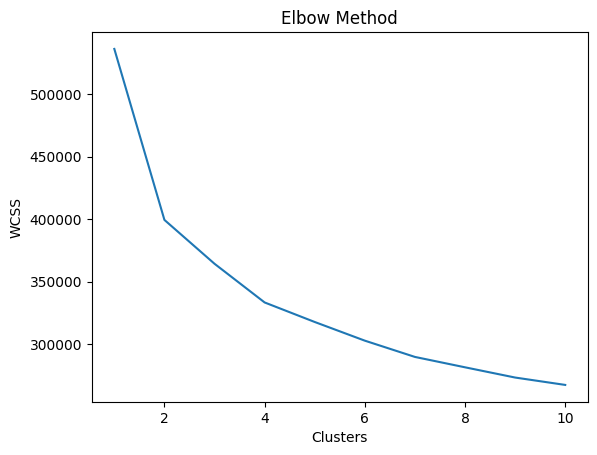

In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

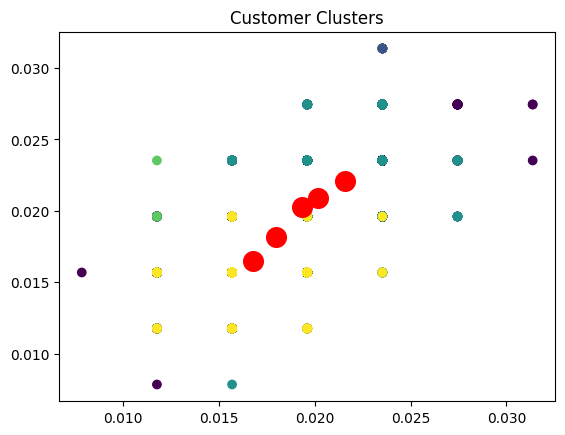

In [37]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=y_kmeans, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            s=200, c='red')
plt.title("Customer Clusters")
plt.show()

In [39]:
clusters = [
    "Cluster 0: High income - low spending",
    "Cluster 1: Medium income - high spending",
    "Cluster 2: Low income - low spending"
]

for c in clusters:
    print(c)

Cluster 0: High income - low spending
Cluster 1: Medium income - high spending
Cluster 2: Low income - low spending
